### **3.2 Baseline Model**

In this practical, you'll build your first baseline models for time series forecasting. A baseline model is a simple, intuitive approach to prediction - often based on straightforward rules or heuristics - and acts as a reference point for evaluating more complex models later on.

Using quarterly earnings data from Johnson & Johnson, you will explore how features like trend and seasonality affect forecasts and learn to construct several naive forecasting models.

The dataset for this practical is the `JohnsonAndJohnson.csv` file.

This activity has been adapted from [this book](https://www.manning.com/books/time-series-forecasting-in-python-book)

**Step 1: Import Libraries and Read the Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
df = pd.read_csv('./data/JohnsonAndJohnson_4.csv')
df.head()

,time,JohnsonJohnson
0,1/1/1960,0.71
1,1/4/1960,0.63
2,2/7/1960,0.85
3,1/10/1960,0.44
4,1/1/1961,0.61


**Step 2: Check if the time attribute is DateTime, otherwise convert to DateTime datatype**

We will do the following:

- check the data type

- convert to datatime data type (if needed)

- check the head() and tail() to inspect the data values

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            84 non-null     str    
 1   JohnsonJohnson  84 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.4 KB


In [4]:
df["time"] = pd.to_datetime(df["time"], dayfirst=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   time            84 non-null     datetime64[us]
 1   JohnsonJohnson  84 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.4 KB


In [5]:
df.head()

,time,JohnsonJohnson
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [6]:
df.tail()

,time,JohnsonJohnson
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


Our data time is now `Year-Month-Day`

**Step 3: Let's look at the data**

We will plot the data.

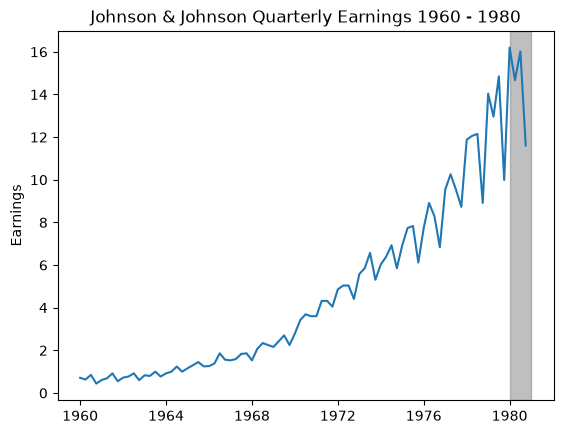

In [8]:
# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the time series using the datetime index
ax.plot(df["time"], df["JohnsonJohnson"])
ax.set_ylabel('Earnings')
ax.set_title('Johnson & Johnson Quarterly Earnings 1960 - 1980')

# Shadow the window we want to predict (last year, i.e. 1980)
ax.axvspan(datetime(1980, 1, 1), datetime(1980, 12, 31), color='gray', alpha=0.5)
plt.show()

**Step 4: Split to train/test**

We are going to split the data into two parts: one for training the model and one for testing how well it works. Since we want to forecast one year ahead, we will use all the data from 1960 to 1979 to train the model. The data from 1980 will be used to check how accurate our predictions are.

To split the data, we will keep everything except the last four rows for training, and use the last four rows as our test set.

**Since the data is quarterly (one row per quarter), four data points represent one full year** - which matches our forecast horizon. The next code block shows how to do this.

In [9]:
# Split the data to keep the last year as testing data
train = df[:-4]
test = df[-4:]

**Step 5: Forecasting using Historical Mean**

Now we are ready to build our **baseline model**. We will start with the simplest possible approach: predicting the **average value** from the training set for every point in the test set.

To calculate the average, we will use the **Numpy** library - a fast and efficient tool for scientific computing in Python that works smoothly with Pandas DataFrames.

In [10]:
# compute for the mean from 1960 to 1979
historical_mean = train["JohnsonJohnson"].mean()
historical_mean

np.float64(4.308499987499999)

We will naively forecast this value for each quarter of 1980.

In [11]:
# Create a new DataFrame to compare actual vs predicted values using the historical mean
pred_hist_mean = pd.DataFrame()

# Add time column from the test set
pred_hist_mean["time"] = test["time"]

# Add actual values from the test set
pred_hist_mean["JohnsonJohnson"] = test["JohnsonJohnson"]

# Add predicted values using the historical mean
pred_hist_mean["pred"] = historical_mean

# Display the DataFrame
pred_hist_mean

,time,JohnsonJohnson,pred
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


**Step 6: Use MAPE to calculate error**

Mean Absolute Percentage Error (MAPE) is a measure of prediction accuracy for forecasting methods that is easy to interpret and independent of the scale of our data. This means that whether we are working with two-digit values or six-digit values, the MAPE will always be expreessed as a percentage. MAPE returns the percentage of how much the forecast values deviate from the observed or actual values on average, whether the prediction was higher or lower than the observed values.

We will define a MAPE function that takes in two vectors: y_true for the actual values observed in the test set and y_pred for the forecast values. In this case, because numpy allows us to work with arrays, we will not need a loop to sum all the values. We can simply subtract the y_pred array from the y_true array and divide by y_true to get the percentage error. Then we can take the absolute value. After that, we take the mean of the result, which will take care of summing up each value in the vector and dividing by the number of predictions.

For details for the formula, you can check it [here](https://www.statisticshowto.com/mean-absolute-percentage-error-mape/).

In [12]:
def mape(y_true, y_pred):
    """
    Calculate the Mean Absolute Percentage Error (MAPE) between true and predicted values.
    
    Parameters:
    y_true (array-like): True values.
    y_pred (array-like): Predicted values.
    
    Returns:
    float: MAPE value.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [13]:
# Compute the MAPE of our baseline model
mape_value = mape(pred_hist_mean["JohnsonJohnson"], pred_hist_mean["pred"])
mape_value

np.float64(70.00752579965119)